# Loan Default Prediction

In [1]:
%load_ext autoreload
%autoreload 2

from scripts.utilities import *
from scripts.features import *

## 1. Load and Process Data

In [2]:
 # Load raw data
consumer_df, account_df, transaction_df = get_data()

# Filter consumers with no transaction or balance information
#consumer_df, account_df, transaction_df = filter_unknown(consumer_df, account_df, transaction_df)

Data successfully loaded and processed.


In [3]:
consumer_df

,prism_consumer_id,evaluation_date,credit_score,DQ_TARGET
0,0,2021-09-01,726.0,0.0
1,1,2021-07-01,626.0,0.0
2,2,2021-05-01,680.0,0.0
3,3,2021-03-01,734.0,0.0
4,4,2021-10-01,676.0,0.0
...,...,...,...,...
14995,14995,2022-03-08,655.0,NaN
14996,14996,2022-01-15,625.0,NaN
14997,14997,2022-01-31,688.0,NaN
14998,14998,2022-03-08,722.0,NaN


In [4]:
transaction_df

,prism_consumer_id,prism_transaction_id,amount,credit_or_debit,posted_date,category
0,3023,0,0.05,CREDIT,2021-04-16,MISCELLANEOUS
1,3023,1,481.56,CREDIT,2021-04-30,LOAN
2,3023,2,0.05,CREDIT,2021-05-16,MISCELLANEOUS
3,3023,3,0.07,CREDIT,2021-06-16,MISCELLANEOUS
4,3023,4,0.06,CREDIT,2021-07-16,MISCELLANEOUS
...,...,...,...,...,...,...
6407316,10533,6405304,4.96,DEBIT,2022-03-11,BILLS_UTILITIES
6407317,10533,6405305,63.48,DEBIT,2022-03-30,LOAN
6407318,10533,6405306,53.99,DEBIT,2022-03-30,LOAN
6407319,10533,6405307,175.98,DEBIT,2022-03-31,LOAN


## Scoring Exclusion
Filtering out consumers with thin files





In [5]:
enriched_df = identify_thin_files(
    transaction_df, 
    account_df, 
    consumer_df,
    min_transactions=3,
    min_transaction_months=1,
    min_balance_records=1
)

# Analyze thin file characteristics
analyze_thin_files(enriched_df)

# Filter out thin files before feature creation
thick_file_consumers = enriched_df[~enriched_df['is_thin_file']]['prism_consumer_id']

# Filter your dataframes
filtered_consumer_df = consumer_df[consumer_df['prism_consumer_id'].isin(thick_file_consumers)]
filtered_account_df = account_df[account_df['prism_consumer_id'].isin(thick_file_consumers)]
filtered_transaction_df = transaction_df[transaction_df['prism_consumer_id'].isin(thick_file_consumers)]

Data Sufficiency Analysis
--------------------------------------------------

Overall Thin File Rate:
is_thin_file
False    0.826
True     0.174
Name: proportion, dtype: float64

Insufficiency Reasons:

insufficient_transactions:
insufficient_transactions
False    0.948
True     0.052
Name: proportion, dtype: float64

insufficient_transaction_history:
insufficient_transaction_history
False    0.966
True     0.034
Name: proportion, dtype: float64

insufficient_balance_records:
insufficient_balance_records
False    0.867
True     0.133
Name: proportion, dtype: float64

Default Rates Comparison:
Thin Files Default Rate: 0.072
Thick Files Default Rate: 0.086

Data Metrics Distribution:

total_transactions:
count    15000.00
mean       427.15
std        397.57
min          0.00
25%        154.00
50%        337.00
75%        589.00
max       8478.00
Name: total_transactions, dtype: float64

months_with_transactions:
count    15000.00
mean         5.97
std          2.62
min          0.00
25% 

In [6]:
analyze_exclusion_impact(consumer_df, filtered_consumer_df)

Exclusion Impact Analysis
--------------------------------------------------

Sample Size Impact:
Original samples: 15000
Filtered samples: 12392
Reduction: 17.4%

Default Rate Impact:
Original default rate: 0.084
Filtered default rate: 0.086

Credit Score Distribution:
Original:
count    15000.00
mean       661.19
std         76.53
min        353.00
25%        618.00
50%        661.00
75%        712.00
max        850.00
Name: credit_score, dtype: float64

Filtered:
count    12392.00
mean       661.38
std         79.33
min        353.00
25%        614.00
50%        661.00
75%        716.00
max        850.00
Name: credit_score, dtype: float64


In [7]:
# replace the original dataframes with the filtered dataframes
consumer_df = filtered_consumer_df
account_df = filtered_account_df
transaction_df = filtered_transaction_df

# display filtered dataframes
consumer_df

,prism_consumer_id,evaluation_date,credit_score,DQ_TARGET
0,0,2021-09-01,726.0,0.0
1,1,2021-07-01,626.0,0.0
2,2,2021-05-01,680.0,0.0
3,3,2021-03-01,734.0,0.0
4,4,2021-10-01,676.0,0.0
...,...,...,...,...
14991,14991,2022-01-26,667.0,NaN
14992,14992,2022-03-14,709.0,NaN
14994,14994,2022-01-15,616.0,NaN
14996,14996,2022-01-15,625.0,NaN


## Feature Creation

In [8]:
# Define feature functions
selected_features = [
    average_transaction_amount,
    net_monthly_cash_flow,
    average_account_balance,
    time_based_average_transaction_amounts,
    descriptive_stats_by_category,
    outflow_stats,
    outflow_over_time_fix,
    balance_over_time
]

# Calculate features
feature_dataframes = execute_selected_features(selected_features, account_df, transaction_df)
final_features = merge_features(feature_dataframes)

# Merge with consumer data
ml_features = consumer_df.merge(final_features, how="left", on="prism_consumer_id")
ml_features = ml_features.apply(lambda col: col.fillna(0) if col.name != "DQ_TARGET" else col)


Feature Execution Plan:
- Total feature creation functions: 8
- Unchanged feature creation functions: 8 (using cached results)

No feature creation functions need to be executed.
- Using cached result for average_transaction_amount
- Using cached result for net_monthly_cash_flow
- Using cached result for average_account_balance
- Using cached result for time_based_average_transaction_amounts
- Using cached result for descriptive_stats_by_category
- Using cached result for outflow_stats
- Using cached result for outflow_over_time_fix
- Using cached result for balance_over_time

Total Created Features:  266


## 2 Split Data

In [9]:
# Split with validation set for hyperparameter tuning
train_df, _, test_df = split_data(ml_features, test_size=0.25)

# Define feature columns
exclude_columns = ['prism_consumer_id', 'evaluation_date', 'credit_score', 'DQ_TARGET']
all_feature_columns = [col for col in train_df.columns if col not in exclude_columns]

Training set size: 7447
No validation set created.
Test set size: 2483


## 3. All Model Performances

In [10]:
summary_table = evaluate_feature_model_combinations(train_df, test_df, all_feature_columns)

Evaluating: Feature Selection = all_features, Model = xgboost
Evaluating: Feature Selection = all_features, Model = gradient_boosting
Evaluating: Feature Selection = all_features, Model = random_forest
Evaluating: Feature Selection = all_features, Model = logistic
Evaluating: Feature Selection = mutual_info, Model = xgboost
Evaluating: Feature Selection = mutual_info, Model = gradient_boosting
Evaluating: Feature Selection = mutual_info, Model = random_forest
Evaluating: Feature Selection = mutual_info, Model = logistic
Evaluating: Feature Selection = random_forest, Model = xgboost
Evaluating: Feature Selection = random_forest, Model = gradient_boosting
Evaluating: Feature Selection = random_forest, Model = random_forest
Evaluating: Feature Selection = random_forest, Model = logistic
Evaluating: Feature Selection = xgboost, Model = xgboost
Evaluating: Feature Selection = xgboost, Model = gradient_boosting
Evaluating: Feature Selection = xgboost, Model = random_forest
Evaluating: Featur

In [11]:
summary_table

,Feature Selection,Model,Test Accuracy,Test Balanced Accuracy,Test ROC AUC
0,all_features,xgboost,0.79,0.72,0.80
1,all_features,gradient_boosting,0.92,0.53,0.81
2,all_features,random_forest,0.92,0.52,0.78
3,all_features,logistic,0.69,0.71,0.74
4,mutual_info,xgboost,0.76,0.71,0.81
5,mutual_info,gradient_boosting,0.92,0.54,0.79
6,mutual_info,random_forest,0.92,0.52,0.79
7,mutual_info,logistic,0.65,0.70,0.75
8,random_forest,xgboost,0.76,0.71,0.80
9,random_forest,gradient_boosting,0.92,0.52,0.80


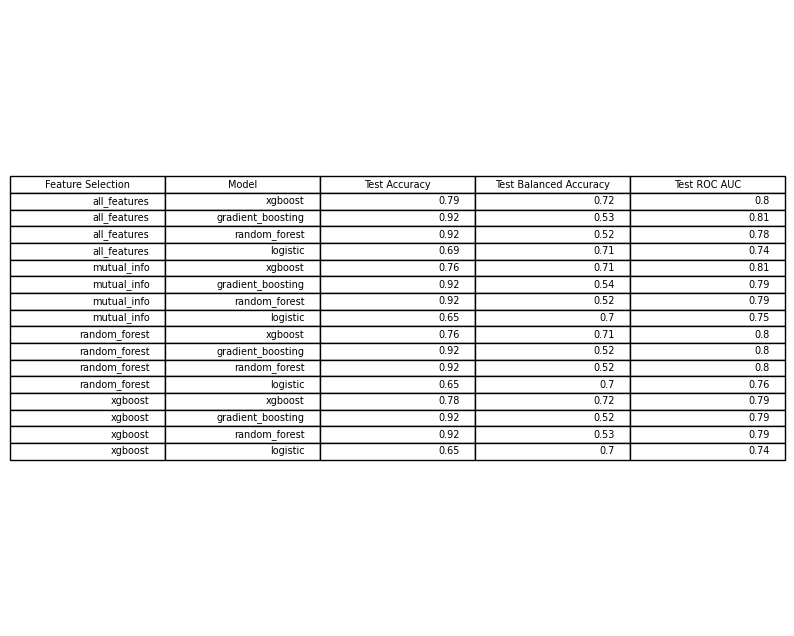

In [12]:
# Set up the matplotlib figure and axis
fig, ax = plt.subplots(figsize=(len(summary_table.columns) * 2, len(summary_table) * 0.5))
ax.axis('tight')
ax.axis('off')

# Create the table plot from the DataFrame
table = ax.table(cellText=summary_table.values, colLabels=summary_table.columns, loc='center')
 
# Save the figure as an image file
plt.show()

## 4. Individual Model Training

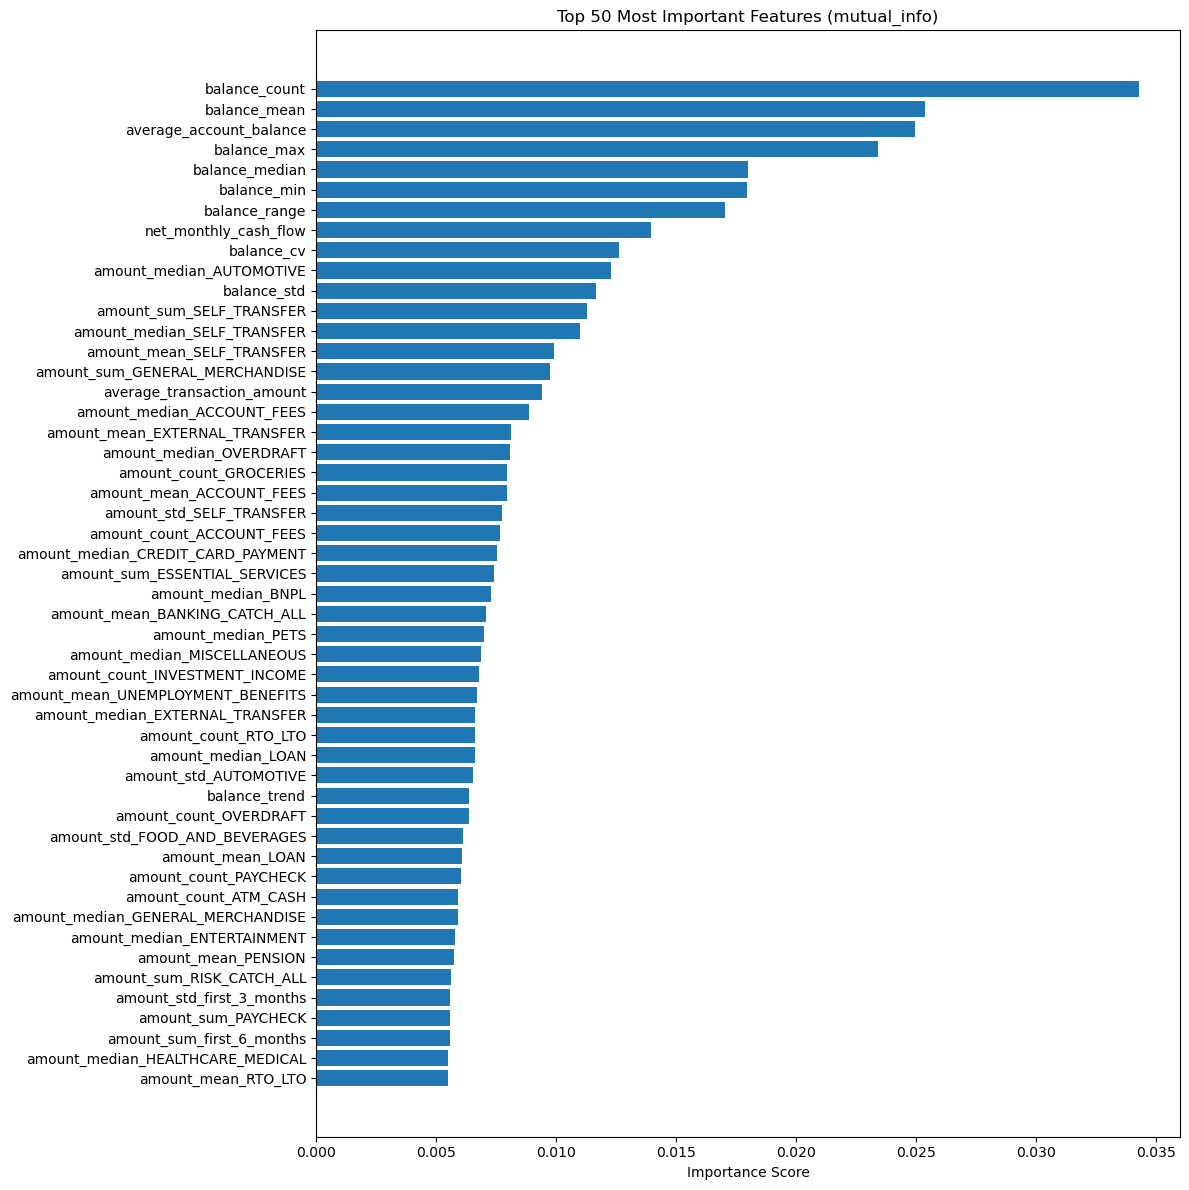

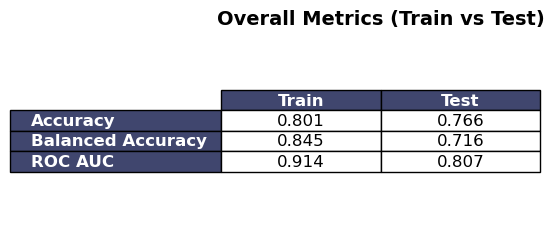


=== Classification Report (Train vs Test) ===
                 Train                                       Test                                 
             precision    recall  f1-score      support precision    recall  f1-score      support
0.0           0.987702  0.791906  0.879033  6795.000000  0.961915  0.775779  0.858878  2279.000000
1.0           0.292646  0.897239  0.441343   652.000000  0.207752  0.656863  0.315665   204.000000
accuracy      0.801128  0.801128  0.801128     0.801128  0.766009  0.766009  0.766009     0.766009
macro avg     0.640174  0.844573  0.660188  7447.000000  0.584834  0.716321  0.587272  2483.000000
weighted avg  0.926848  0.801128  0.840712  7447.000000  0.899954  0.766009  0.814248  2483.000000


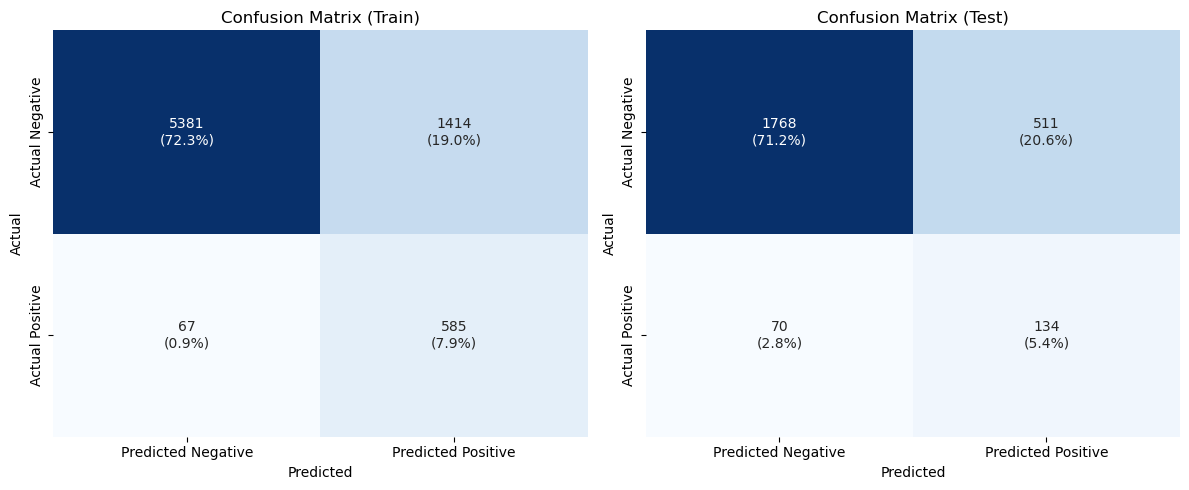

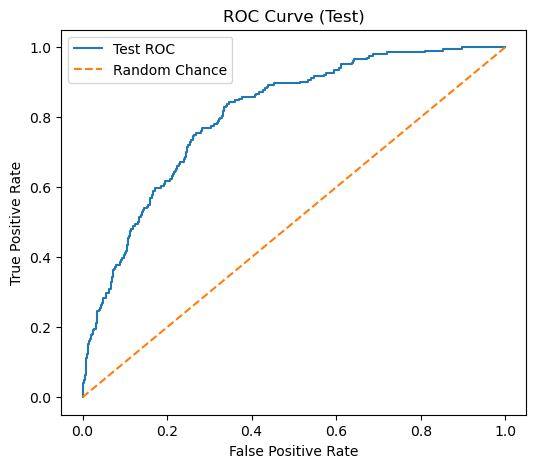

In [13]:
# Initialize the feature selector with your training DataFrame, feature columns, and any forced features.
fs = FeatureSelector(train_df, all_feature_columns)

# Run feature selection using the desired method(s)
# available --> ['mutual_info', 'random_forest', 'xgboost']
fs.run_feature_selection(methods=['mutual_info'], n_features=50)

# Retrieve the selected features for a given method
feature_columns = fs.get_selected_features('mutual_info')

# Plot the importance scores for the selected method
fs.plot_feature_importance('mutual_info', top_n=50)

# Initialize and train model with all features
X_train, X_train_scaled, model, scaler = train_model(train_df, feature_columns, "xgboost")
X_test, X_test_scaled, y_test, y_pred_test, results = predict_and_analyze_model(model, scaler, train_df, test_df, feature_columns)


Model Architecture:


/Users/qianjin/anaconda3/envs/creditrisk/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)


Class Distribution:
DQ_TARGET
0.0    0.912448
1.0    0.087552
Name: proportion, dtype: float64

Class Weights:
{0: 0.5479764532744665, 1: 5.710889570552148}
Epoch 1/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - AUC: 0.5902 - accuracy: 0.5606 - loss: 0.7085 - val_AUC: 0.7059 - val_accuracy: 0.6604 - val_loss: 0.6306
Epoch 2/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 794us/step - AUC: 0.7316 - accuracy: 0.6630 - loss: 0.6325 - val_AUC: 0.7144 - val_accuracy: 0.6805 - val_loss: 0.5887
Epoch 3/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 756us/step - AUC: 0.7358 - accuracy: 0.6546 - loss: 0.6273 - val_AUC: 0.7231 - val_accuracy: 0.6557 - val_loss: 0.5896
Epoch 4/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 766us/step - AUC: 0.7556 - accuracy: 0.6484 - loss: 0.6056 - val_AUC: 0.7260 - val_accuracy: 0.6443 - val_loss: 0.5884
Epoch 5/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 767us/step - AUC: 0.7557 - accuracy: 0.6550 - loss: 0.5995 - val_AUC: 0.7231 - val_accuracy: 0.6557 - val_loss: 0.5772
Epoch 6/100
187/187 ━━━━━━━━━

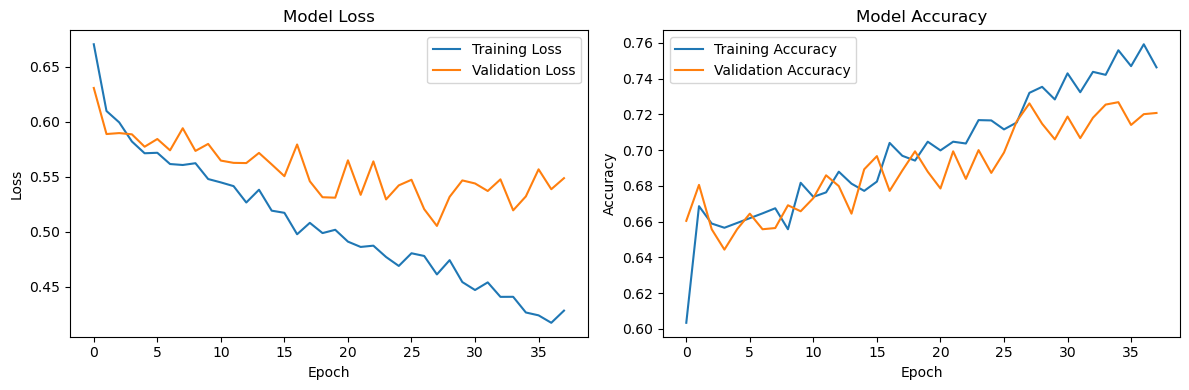


Input Data Statistics:
Mean: 1.7365217927801562e-18
Std: 0.9999999999999999
Min: -26.931858510311756
Max: 86.17061441605979

Prediction Distribution:
0    0.719291
1    0.280709
Name: proportion, dtype: float64

Prediction Distribution:
0    0.70431
1    0.29569
Name: proportion, dtype: float64


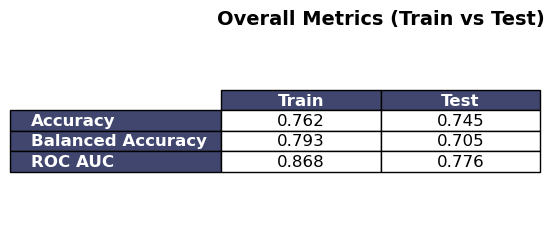


=== Classification Report (Train vs Test) ===
                 Train                                      Test                                 
             precision    recall  f1-score     support precision    recall  f1-score      support
0.0           0.979028  0.755703  0.852990  6795.00000  0.960806  0.752962  0.844280  2279.000000
1.0           0.246140  0.831288  0.379818   652.00000  0.192253  0.656863  0.297447   204.000000
accuracy      0.762320  0.762320  0.762320     0.76232  0.745066  0.745066  0.745066     0.745066
macro avg     0.612584  0.793496  0.616404  7447.00000  0.576529  0.704912  0.570864  2483.000000
weighted avg  0.914862  0.762320  0.811563  7447.00000  0.897663  0.745066  0.799353  2483.000000


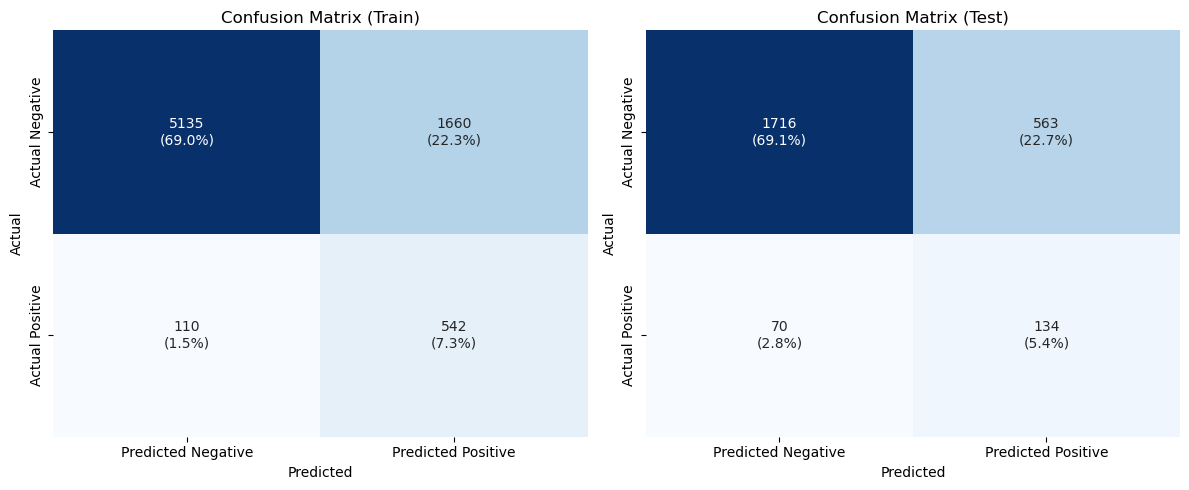

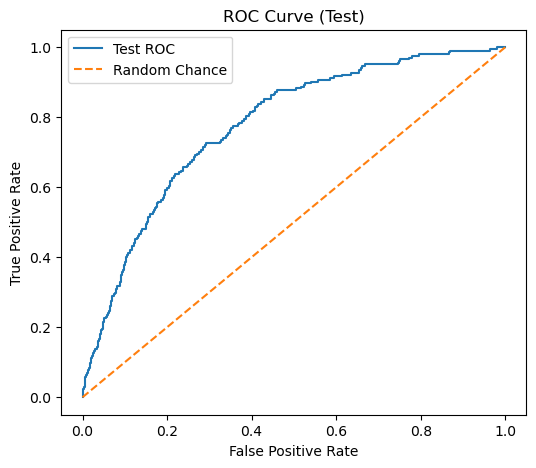

In [14]:
# Retrieve the selected features for a given method
feature_columns = fs.get_selected_features('mutual_info')

# Initialize and train model with selected features
X_train, X_train_scaled, nn_model, scaler = train_model(train_df, feature_columns, "neural_network")

# Check the scale of the input data
print("\nInput Data Statistics:")
print("Mean:", X_train_scaled.mean())
print("Std:", X_train_scaled.std())
print("Min:", X_train_scaled.min())
print("Max:", X_train_scaled.max())

# Analyze model performance
results = predict_and_analyze_model(
    nn_model, 
    scaler, 
    train_df, 
    test_df, 
    feature_columns,
    show_metrics=True,
    show_classification_report=True,
    show_confusion_matrix=True,
    show_roc_curve=True
)

## 5. SHAP

- Most impactful features for the model overall (according to SHAP):

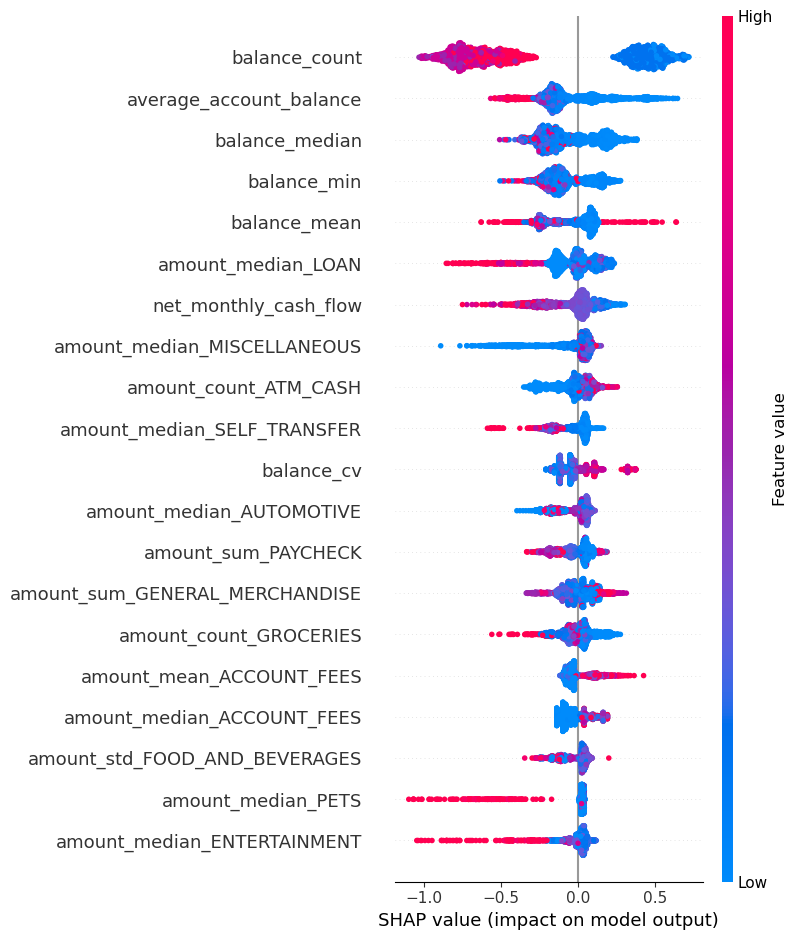

In [15]:
scaled_feats, explainer, shap_values = shap_plots(model, X_test, X_test_scaled)

- Waterfall plot for an individual person:
    - Person here was predicted as not defaulting

In [16]:
y_pred_test[0]

0

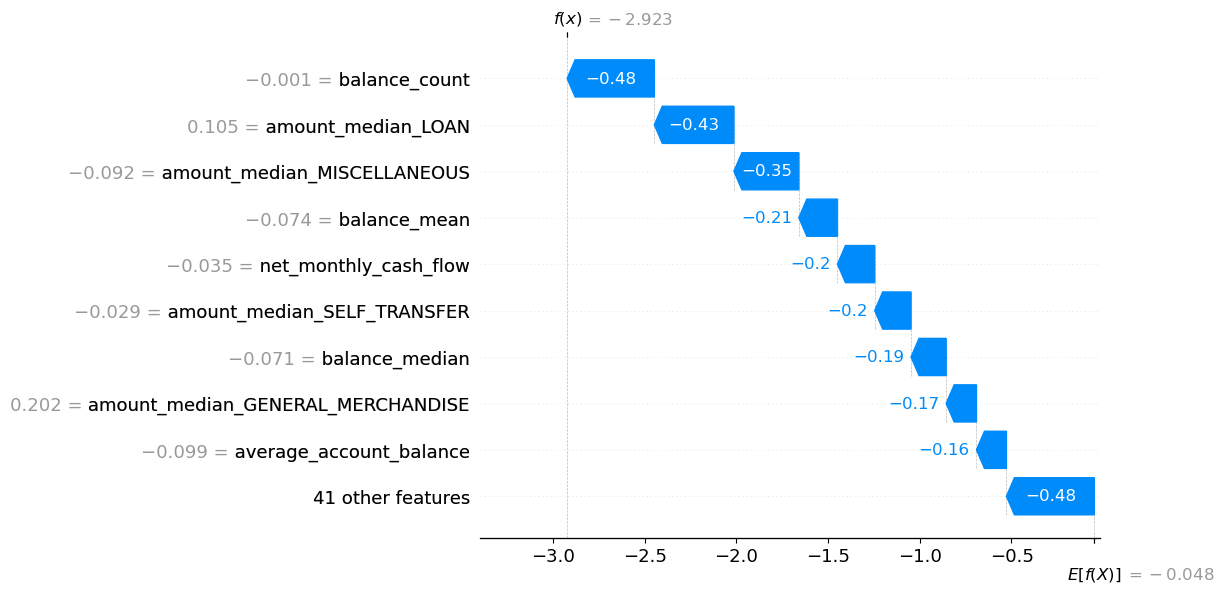

In [17]:
shap.plots.waterfall(shap_values[0])

- Reason codes for default:

In [18]:
scaled_feats['y_true'] = y_test.values
scaled_feats['y_pred'] = y_pred_test

shap_values = explainer(scaled_feats.drop(columns=['y_true', 'y_pred']))

shap_df = pd.DataFrame(shap_values.values, columns=scaled_feats.drop(columns=['y_true', 'y_pred']).columns)

mask = scaled_feats['y_pred'] == 1
shap_df_pred_default = shap_df[mask].reset_index(drop=True)

def get_top_feature_names(shap_row, feature_names, top_n=3):
    top_indices = np.argsort(shap_row)[::-1][:top_n]  
    return [feature_names[i] for i in top_indices]  

top_features_pred_default = shap_df_pred_default.apply(
    lambda row: get_top_feature_names(row, shap_df.columns), axis=1
)

top_features_df = pd.DataFrame(top_features_pred_default.tolist(), columns=['Feature_1', 'Feature_2', 'Feature_3'])
top_features_df

,Feature_1,Feature_2,Feature_3
0,balance_count,amount_mean_ACCOUNT_FEES,amount_std_FOOD_AND_BEVERAGES
1,balance_count,balance_median,average_account_balance
2,balance_count,balance_median,balance_mean
3,balance_count,amount_count_GROCERIES,balance_median
4,balance_count,balance_min,amount_mean_ACCOUNT_FEES
...,...,...,...
640,balance_count,average_account_balance,balance_median
641,balance_cv,net_monthly_cash_flow,amount_mean_ACCOUNT_FEES
642,balance_count,average_account_balance,balance_median
643,amount_median_LOAN,amount_median_BNPL,amount_sum_PAYCHECK


In [19]:
top_features_pred_default.explode().value_counts()

balance_count                        578
balance_median                       330
average_account_balance              243
balance_min                          123
amount_mean_ACCOUNT_FEES              85
amount_median_LOAN                    81
net_monthly_cash_flow                 69
amount_sum_GENERAL_MERCHANDISE        68
balance_mean                          60
balance_cv                            42
amount_mean_RTO_LTO                   37
amount_count_GROCERIES                36
amount_median_OVERDRAFT               36
amount_median_EXTERNAL_TRANSFER       26
amount_median_BNPL                    20
amount_count_ATM_CASH                 16
amount_sum_SELF_TRANSFER              11
amount_median_GENERAL_MERCHANDISE     10
amount_mean_BANKING_CATCH_ALL          9
amount_sum_PAYCHECK                    9
amount_median_AUTOMOTIVE               7
amount_median_CREDIT_CARD_PAYMENT      5
amount_median_ACCOUNT_FEES             5
amount_count_ACCOUNT_FEES              4
amount_count_OVE